# Feature Engineering - Pantau Pasar
Tambah fitur kalender ke data PIHPS untuk membantu model menangkap pola musiman.

Tahap ini dikerjakan dua bagian:
1. Flag hari libur nasional + periode Ramadan (notebook ini)
2. Data cuaca dari Open-Meteo API (notebook ini, section berikutnya)

Output: `data/cleaned/pihps_featured.csv`

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

df = pd.read_csv('data/cleaned/pihps_cleaned.csv', parse_dates=['tanggal'])

print(f'Loaded: {df.shape[0]:,} baris | {df.tanggal.min().date()} s/d {df.tanggal.max().date()}')
df.head(3)

Loaded: 23,709 baris | 2022-01-03 s/d 2026-04-30


,Komoditas,tanggal,harga,sumber,is_outlier
0,Bawang Merah Ukuran Sedang,2022-01-03,30200.0,PIHPS,False
1,Bawang Merah Ukuran Sedang,2022-01-04,30150.0,PIHPS,False
2,Bawang Merah Ukuran Sedang,2022-01-05,30300.0,PIHPS,False


## 1. Hari Libur Nasional (`is_holiday`)
Sumber: Peraturan Pemerintah + SKB 3 Menteri untuk cuti bersama tiap tahun.
Mencakup hari libur resmi dan cuti bersama karena keduanya mempengaruhi aktivitas pasar.

In [10]:
LIBUR_NASIONAL = [
    # 2022
    '2022-01-01',  # Tahun Baru Masehi
    '2022-02-01',  # Tahun Baru Imlek 2573
    '2022-03-03',  # Isra Mi'raj + Hari Raya Nyepi
    '2022-04-15',  # Wafat Isa Al-Masih
    '2022-04-29',  # Cuti bersama Lebaran
    '2022-05-01',  # Hari Buruh Internasional
    '2022-05-02',  # Idul Fitri 1443H (hari ke-1)
    '2022-05-03',  # Idul Fitri 1443H (hari ke-2)
    '2022-05-04',  # Cuti bersama Lebaran
    '2022-05-05',  # Cuti bersama Lebaran
    '2022-05-06',  # Cuti bersama Lebaran
    '2022-05-16',  # Hari Raya Waisak 2566
    '2022-05-26',  # Kenaikan Isa Al-Masih
    '2022-06-01',  # Hari Lahir Pancasila
    '2022-07-10',  # Idul Adha 1443H
    '2022-07-11',  # Cuti bersama Idul Adha
    '2022-07-30',  # Tahun Baru Islam 1444H
    '2022-08-17',  # HUT RI ke-77
    '2022-10-08',  # Maulid Nabi Muhammad SAW
    '2022-12-25',  # Hari Raya Natal
    '2022-12-26',  # Cuti bersama Natal
    # 2023
    '2023-01-01',  # Tahun Baru Masehi
    '2023-01-22',  # Tahun Baru Imlek 2574
    '2023-02-18',  # Isra Mi'raj
    '2023-03-22',  # Hari Raya Nyepi 1945 Saka
    '2023-04-07',  # Wafat Isa Al-Masih
    '2023-04-19',  # Cuti bersama Lebaran
    '2023-04-20',  # Cuti bersama Lebaran
    '2023-04-21',  # Cuti bersama Lebaran
    '2023-04-22',  # Idul Fitri 1444H (hari ke-1)
    '2023-04-23',  # Idul Fitri 1444H (hari ke-2)
    '2023-04-24',  # Cuti bersama Lebaran
    '2023-04-25',  # Cuti bersama Lebaran
    '2023-05-01',  # Hari Buruh Internasional
    '2023-05-18',  # Kenaikan Isa Al-Masih
    '2023-06-01',  # Hari Lahir Pancasila
    '2023-06-04',  # Hari Raya Waisak 2567
    '2023-06-28',  # Idul Adha 1444H (hari ke-1)
    '2023-06-29',  # Idul Adha 1444H (hari ke-2)
    '2023-07-19',  # Tahun Baru Islam 1445H
    '2023-08-17',  # HUT RI ke-78
    '2023-09-28',  # Maulid Nabi Muhammad SAW
    '2023-12-25',  # Hari Raya Natal
    '2023-12-26',  # Cuti bersama Natal
    # 2024
    '2024-01-01',  # Tahun Baru Masehi
    '2024-02-08',  # Isra Mi'raj
    '2024-02-10',  # Tahun Baru Imlek 2575
    '2024-03-11',  # Hari Raya Nyepi 1946 Saka
    '2024-03-29',  # Wafat Isa Al-Masih
    '2024-04-08',  # Cuti bersama Lebaran
    '2024-04-09',  # Cuti bersama Lebaran
    '2024-04-10',  # Idul Fitri 1445H (hari ke-1)
    '2024-04-11',  # Idul Fitri 1445H (hari ke-2)
    '2024-04-12',  # Cuti bersama Lebaran
    '2024-04-15',  # Cuti bersama Lebaran
    '2024-05-01',  # Hari Buruh Internasional
    '2024-05-09',  # Kenaikan Isa Al-Masih
    '2024-05-23',  # Hari Raya Waisak 2568
    '2024-06-01',  # Hari Lahir Pancasila
    '2024-06-17',  # Idul Adha 1445H
    '2024-06-18',  # Cuti bersama Idul Adha
    '2024-07-07',  # Tahun Baru Islam 1446H
    '2024-08-17',  # HUT RI ke-79
    '2024-09-16',  # Maulid Nabi Muhammad SAW
    '2024-12-25',  # Hari Raya Natal
    '2024-12-26',  # Cuti bersama Natal
    # 2025
    '2025-01-01',  # Tahun Baru Masehi
    '2025-01-27',  # Isra Mi'raj
    '2025-01-28',  # Cuti bersama Imlek
    '2025-01-29',  # Tahun Baru Imlek 2576
    '2025-03-28',  # Cuti bersama Lebaran
    '2025-03-29',  # Hari Raya Nyepi 1947 Saka
    '2025-03-31',  # Idul Fitri 1446H (hari ke-1)
    '2025-04-01',  # Idul Fitri 1446H (hari ke-2)
    '2025-04-02',  # Cuti bersama Lebaran
    '2025-04-03',  # Cuti bersama Lebaran
    '2025-04-04',  # Cuti bersama Lebaran
    '2025-04-18',  # Wafat Isa Al-Masih
    '2025-05-01',  # Hari Buruh Internasional
    '2025-05-12',  # Kenaikan Isa Al-Masih
    '2025-05-13',  # Hari Raya Waisak 2569
    '2025-06-01',  # Hari Lahir Pancasila
    '2025-06-06',  # Idul Adha 1446H (hari ke-1)
    '2025-06-07',  # Idul Adha 1446H (hari ke-2)
    '2025-06-27',  # Tahun Baru Islam 1447H
    '2025-08-17',  # HUT RI ke-80
    '2025-09-05',  # Maulid Nabi Muhammad SAW
    '2025-12-25',  # Hari Raya Natal
    '2025-12-26',  # Cuti bersama Natal
    # 2026 (Jan-Apr)
    '2026-01-01',  # Tahun Baru Masehi
    '2026-01-17',  # Isra Mi'raj
    '2026-02-17',  # Tahun Baru Imlek 2577
    '2026-03-09',  # Hari Raya Nyepi 1948 Saka
    '2026-03-19',  # Cuti bersama Lebaran
    '2026-03-20',  # Idul Fitri 1447H (hari ke-1)
    '2026-03-21',  # Idul Fitri 1447H (hari ke-2)
    '2026-03-23',  # Cuti bersama Lebaran
    '2026-03-24',  # Cuti bersama Lebaran
    '2026-04-03',  # Wafat Isa Al-Masih
]

libur_set = set(pd.to_datetime(LIBUR_NASIONAL).normalize())
df['is_holiday'] = df['tanggal'].dt.normalize().isin(libur_set).astype(int)

print(f'Total tanggal unik dalam data    : {df.tanggal.nunique()}')
print(f'Tanggal yang jatuh di hari libur : {df[df.is_holiday == 1].tanggal.nunique()}')
print(f'Persentase baris dengan is_holiday=1: {df.is_holiday.mean()*100:.1f}%')

Total tanggal unik dalam data    : 1129
Tanggal yang jatuh di hari libur : 77
Persentase baris dengan is_holiday=1: 6.8%


In [11]:
# Cek distribusi hari libur per tahun
holiday_dates = df[df.is_holiday == 1][['tanggal']].drop_duplicates().sort_values('tanggal')
holiday_dates['tahun'] = holiday_dates.tanggal.dt.year

print('Jumlah hari libur per tahun (yang ada datanya):')
print(holiday_dates.groupby('tahun').size().to_string())
print()
print('Daftar tanggal libur:')
for _, row in holiday_dates.iterrows():
    print(f'  {row.tanggal.date()}')

Jumlah hari libur per tahun (yang ada datanya):
tahun
2022    15
2023    17
2024    18
2025    19
2026     8

Daftar tanggal libur:
  2022-02-01
  2022-03-03
  2022-04-15
  2022-04-29
  2022-05-02
  2022-05-03
  2022-05-04
  2022-05-05
  2022-05-06
  2022-05-16
  2022-05-26
  2022-06-01
  2022-07-11
  2022-08-17
  2022-12-26
  2023-03-22
  2023-04-07
  2023-04-19
  2023-04-20
  2023-04-21
  2023-04-24
  2023-04-25
  2023-05-01
  2023-05-18
  2023-06-01
  2023-06-28
  2023-06-29
  2023-07-19
  2023-08-17
  2023-09-28
  2023-12-25
  2023-12-26
  2024-01-01
  2024-02-08
  2024-03-11
  2024-03-29
  2024-04-08
  2024-04-09
  2024-04-10
  2024-04-11
  2024-04-12
  2024-04-15
  2024-05-01
  2024-05-09
  2024-05-23
  2024-06-17
  2024-06-18
  2024-09-16
  2024-12-25
  2024-12-26
  2025-01-01
  2025-01-27
  2025-01-28
  2025-01-29
  2025-03-28
  2025-03-31
  2025-04-01
  2025-04-02
  2025-04-03
  2025-04-04
  2025-04-18
  2025-05-01
  2025-05-12
  2025-05-13
  2025-06-06
  2025-06-27
  2025-09-

## 2. Periode Ramadan (`is_ramadan`)
Flag 1 jika tanggal jatuh dalam bulan Ramadan. Sumber: penetapan awal Ramadan oleh Kemenag RI.

In [12]:
RAMADAN_PERIODS = [
    ('2022-04-02', '2022-05-01'),  # Ramadan 1443H
    ('2023-03-23', '2023-04-21'),  # Ramadan 1444H
    ('2024-03-12', '2024-04-09'),  # Ramadan 1445H
    ('2025-03-01', '2025-03-29'),  # Ramadan 1446H
    ('2026-02-18', '2026-03-19'),  # Ramadan 1447H
]

def in_ramadan(date):
    for start, end in RAMADAN_PERIODS:
        if pd.Timestamp(start) <= date <= pd.Timestamp(end):
            return 1
    return 0

df['is_ramadan'] = df['tanggal'].apply(in_ramadan)

print('Jumlah baris per status Ramadan:')
print(df.groupby('is_ramadan').size().rename({0: 'Non-Ramadan', 1: 'Ramadan'}).to_string())
print()

# Verifikasi per tahun
ramadan_per_tahun = (df[df.is_ramadan == 1]
                     .assign(tahun=df.tanggal.dt.year)
                     .groupby('tahun')['tanggal']
                     .agg(['min', 'max', 'nunique']))
ramadan_per_tahun.columns = ['mulai', 'selesai', 'n_hari']
print('Verifikasi periode Ramadan per tahun:')
print(ramadan_per_tahun.to_string())

Jumlah baris per status Ramadan:
is_ramadan
Non-Ramadan    21504
Ramadan         2205

Verifikasi periode Ramadan per tahun:
           mulai    selesai  n_hari
tahun                              
2022  2022-04-04 2022-04-29      20
2023  2023-03-23 2023-04-21      22
2024  2024-03-12 2024-04-09      21
2025  2025-03-03 2025-03-28      20
2026  2026-02-18 2026-03-19      22


## 3. Kedekatan dengan Lebaran (`days_to_lebaran`)
Selisih hari ke Idul Fitri terdekat. Negatif = sebelum Lebaran, positif = setelah.
Fitur ini membantu model menangkap lonjakan harga di periode pre-Lebaran.

In [13]:
LEBARAN_DATES = [
    pd.Timestamp('2022-05-02'),  # Idul Fitri 1443H
    pd.Timestamp('2023-04-22'),  # Idul Fitri 1444H
    pd.Timestamp('2024-04-10'),  # Idul Fitri 1445H
    pd.Timestamp('2025-03-31'),  # Idul Fitri 1446H
    pd.Timestamp('2026-03-20'),  # Idul Fitri 1447H
]

def days_to_nearest_lebaran(date):
    diffs = [(date - lb).days for lb in LEBARAN_DATES]
    return min(diffs, key=abs)

df['days_to_lebaran'] = df['tanggal'].apply(days_to_nearest_lebaran)

print('Distribusi days_to_lebaran:')
print(df['days_to_lebaran'].describe().round(1).to_string())
print()
print('Sampel hari tepat Lebaran (days_to_lebaran = 0):')
print(df[df.days_to_lebaran == 0][['tanggal', 'Komoditas', 'harga']].head(5).to_string(index=False))

Distribusi days_to_lebaran:
count    23709.0
mean        -3.6
std         98.8
min       -177.0
25%        -87.0
50%         -7.0
75%         79.0
max        177.0

Sampel hari tepat Lebaran (days_to_lebaran = 0):
   tanggal                  Komoditas        harga
2022-05-02 Bawang Merah Ukuran Sedang 39000.000000
2024-04-10 Bawang Merah Ukuran Sedang 42150.000000
2025-03-31 Bawang Merah Ukuran Sedang 47050.000000
2026-03-20 Bawang Merah Ukuran Sedang 44550.000000
2022-05-02 Bawang Putih Ukuran Sedang 32166.666667


## 4. Validasi Visual
Cek apakah fitur-fitur baru masuk akal secara visual.

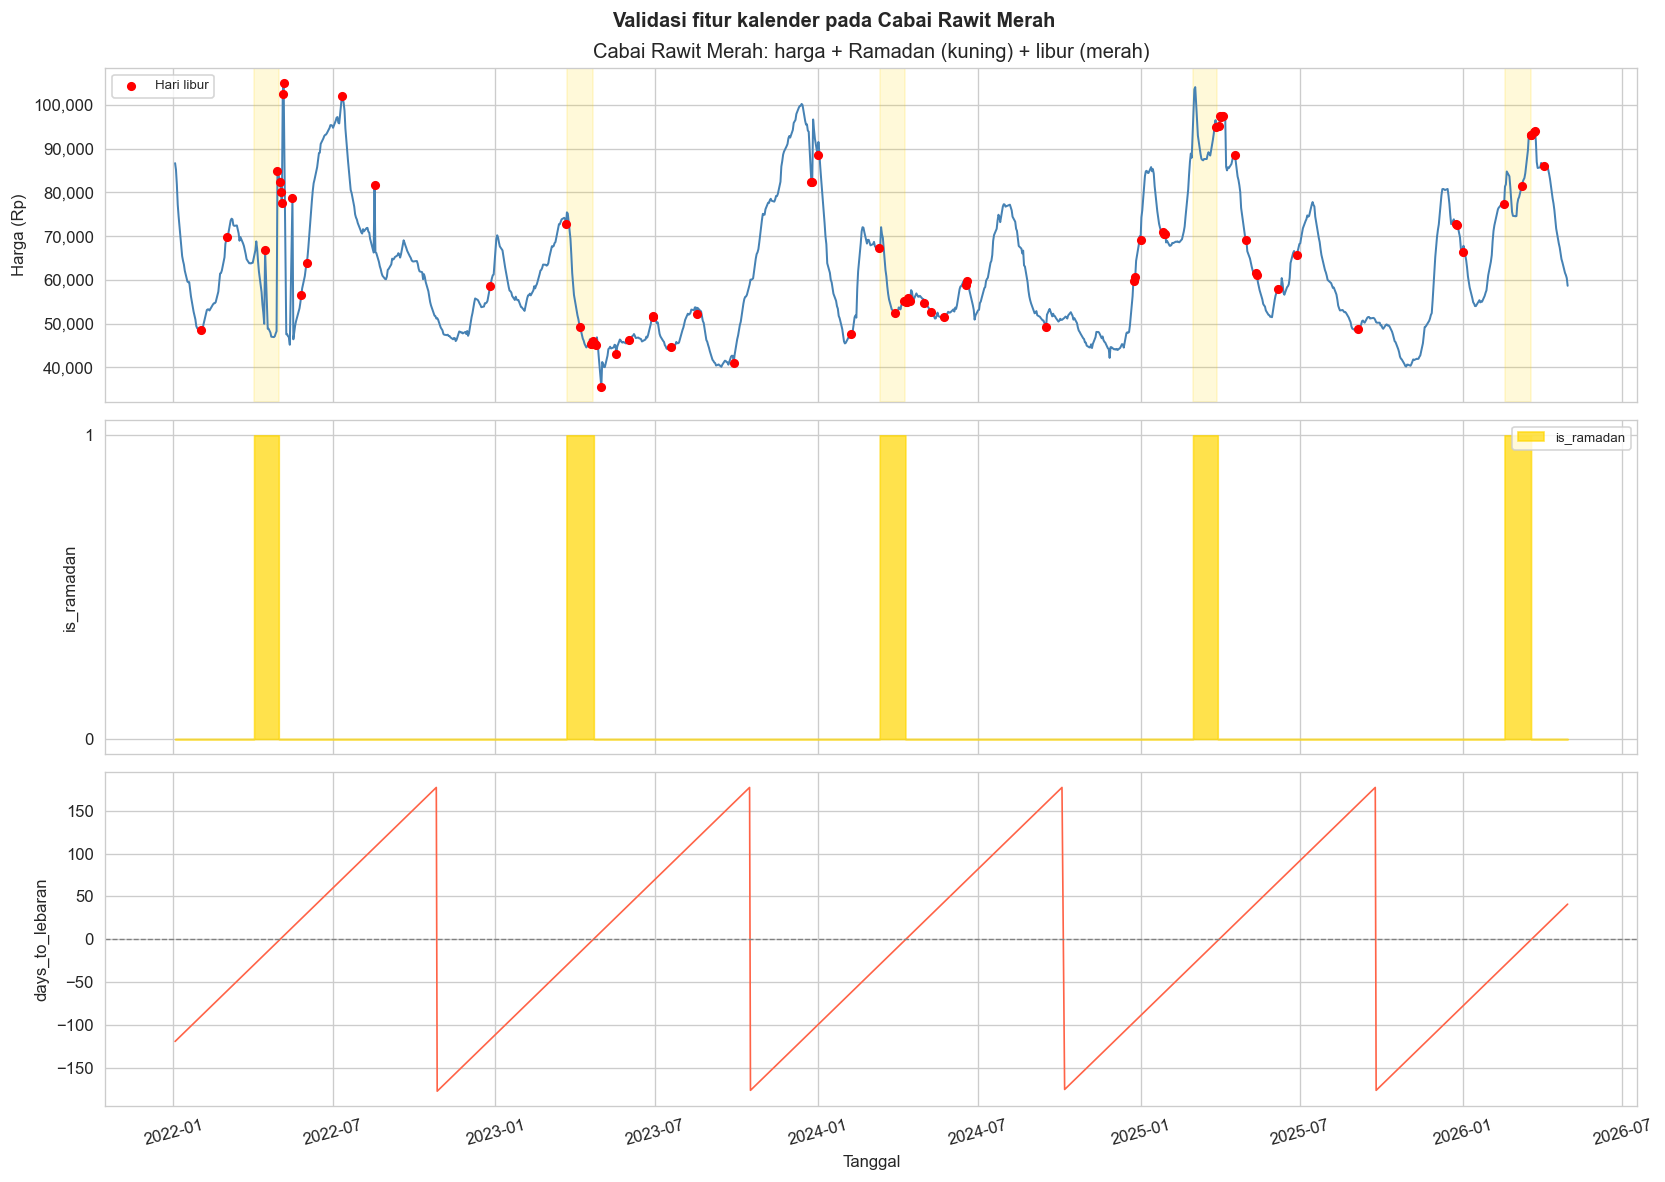

In [14]:
# Ambil satu komoditas volatile untuk validasi
kom = 'Cabai Rawit Merah'
sample = df[df.Komoditas == kom].set_index('tanggal').sort_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: harga + shade Ramadan + titik libur
ax = axes[0]
ax.plot(sample.index, sample['harga'], color='steelblue', linewidth=1.2)
for start, end in RAMADAN_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='gold')
holiday_in_sample = sample[sample.is_holiday == 1]
ax.scatter(holiday_in_sample.index, holiday_in_sample['harga'],
           color='red', s=20, zorder=5, label='Hari libur')
ax.set_ylabel('Harga (Rp)')
ax.set_title(f'{kom}: harga + Ramadan (kuning) + libur (merah)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8)

# Panel 2: is_ramadan
ax = axes[1]
ax.fill_between(sample.index, sample['is_ramadan'], step='mid',
                color='gold', alpha=0.7, label='is_ramadan')
ax.set_ylabel('is_ramadan')
ax.set_yticks([0, 1])
ax.legend(fontsize=8)

# Panel 3: days_to_lebaran
ax = axes[2]
ax.plot(sample.index, sample['days_to_lebaran'], color='tomato', linewidth=1)
ax.axhline(0, ls='--', color='gray', lw=0.8)
ax.set_ylabel('days_to_lebaran')
ax.set_xlabel('Tanggal')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Validasi fitur kalender pada Cabai Rawit Merah', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Cek rata-rata harga saat Ramadan vs non-Ramadan per komoditas
comp = (df.groupby(['Komoditas', 'is_ramadan'])['harga']
          .mean()
          .unstack('is_ramadan')
          .rename(columns={0: 'Non-Ramadan', 1: 'Ramadan'}))
comp['Selisih (%)'] = ((comp['Ramadan'] - comp['Non-Ramadan']) / comp['Non-Ramadan'] * 100).round(1)
comp = comp.sort_values('Selisih (%)', ascending=False).round(0)
print('Rata-rata harga Ramadan vs Non-Ramadan (Rp):')
comp

Rata-rata harga Ramadan vs Non-Ramadan (Rp):


is_ramadan,Non-Ramadan,Ramadan,Selisih (%)
Komoditas,,,
Cabai Rawit Merah,61677.0,68339.0,11.0
Cabai Rawit Hijau,48842.0,51551.0,6.0
Minyak Goreng Curah,17052.0,17983.0,6.0
Minyak Goreng Kemasan Bermerk 2,20698.0,21583.0,4.0
Minyak Goreng Kemasan Bermerk 1,21934.0,22773.0,4.0
Bawang Putih Ukuran Sedang,38191.0,39398.0,3.0
Cabai Merah Besar,50645.0,52182.0,3.0
Daging Ayam Ras Segar,37066.0,38149.0,3.0
Gula Pasir Lokal,16639.0,16900.0,2.0


## 5. Simpan Output
Simpan ke `pihps_featured.csv`. File ini yang akan dipakai AI Engineer untuk training.

In [16]:
df.to_csv('data/cleaned/pihps_featured.csv', index=False)

print('File disimpan: data/cleaned/pihps_featured.csv')
print(f'Shape        : {df.shape}')
print(f'Kolom        : {list(df.columns)}')
print()
print('Catatan untuk AI Engineer:')
print('  - Load dengan: pd.read_csv(..., parse_dates=["tanggal"])')
print('  - is_holiday dan is_ramadan: int 0/1')
print('  - days_to_lebaran: int, negatif = sebelum Lebaran, positif = sesudah')

File disimpan: data/cleaned/pihps_featured.csv
Shape        : (23709, 8)
Kolom        : ['Komoditas', 'tanggal', 'harga', 'sumber', 'is_outlier', 'is_holiday', 'is_ramadan', 'days_to_lebaran']

Catatan untuk AI Engineer:
  - Load dengan: pd.read_csv(..., parse_dates=["tanggal"])
  - is_holiday dan is_ramadan: int 0/1
  - days_to_lebaran: int, negatif = sebelum Lebaran, positif = sesudah


## Selanjutnya: Data Cuaca (Open-Meteo)
Tambah fitur cuaca harian nasional dari Open-Meteo API:
- Koordinat: Jakarta (-6.2, 106.8) sebagai representasi nasional
- Variabel: suhu rata-rata, curah hujan, kecepatan angin
- Join ke `pihps_featured.csv` berdasarkan kolom `tanggal`